# Análise Exploratória de Dados (AED) — VigiAr SP

**Projeto:** VigiAr — sistema preditivo de crise respiratória para o SUS de São Paulo
**Grupo:** DataSquad — FIAP
**Sprint:** 3 — Machine Learning

Este notebook cobre a Análise Exploratória de Dados (AED) do dataset unificado produzido pelo
ETL do projeto (SRAG/SIVEP-Gripe, leitos SUS/CNES, população IBGE e temperatura INMET,
integrados por `municipio` + `semana`), conforme solicitado pelo professor de Estatística:

1. Distribuição das variáveis
2. Medidas de localização e variabilidade
3. Valores faltantes e outliers
4. Relações entre variáveis
5. Análise regional — qual região concentra mais o problema
6. Conclusão da AED

> **Nota de versão:** esta é a base **corrigida**. Uma investigação anterior identificou que a
> troca da chave geográfica para município de residência (`ID_MN_RESI`) deixava passar pacientes
> residentes fora de SP, o que distorcia a classificação regional (91% dos municípios caíam em
> "Centro", e Norte/Sul ficavam vazios). O ETL foi corrigido pra filtrar esses municípios antes
> da geocodificação, e o dataset usado aqui já reflete essa correção — 645 municípios, os cinco
> valores de região com presença real.


## 0. Configuração

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["figure.facecolor"] = "white"

# Paleta única do projeto — usada em todo o notebook pra manter identidade visual
COR_PRINCIPAL = "#0f4c5c"
COR_ALERTA = "#e76f51"
CORES_REGIAO = {
    "Centro": "#0f4c5c",
    "Norte":  "#2a9d8f",
    "Sul":    "#264653",
    "Leste":  "#e76f51",
    "Oeste":  "#e9c46a",
}
ORDEM_REGIOES = ["Centro", "Norte", "Sul", "Leste", "Oeste"]

def estilizar_eixo(eixo, titulo=None, xlabel=None, ylabel=None):
    if titulo: eixo.set_title(titulo, fontsize=12, fontweight="bold", pad=10)
    if xlabel: eixo.set_xlabel(xlabel, fontsize=10)
    if ylabel: eixo.set_ylabel(ylabel, fontsize=10)
    eixo.spines["top"].set_visible(False)
    eixo.spines["right"].set_visible(False)

# Ajuste o caminho se o arquivo estiver em outra pasta
ARQUIVO_DADOS = "/content/vigiar_sp_formatado (4).xlsx"


## 1. Carregamento do dataset unificado

Cada linha é a combinação de **um município** e **uma semana epidemiológica** — a granularidade
definida pelo ETL. `municipio` funciona como chave estrangeira pra região, regional de saúde,
população e leitos; `municipio` + `semana` é a chave composta que une os casos de SRAG com a
temperatura da semana.

In [6]:
import os

if not os.path.exists(ARQUIVO_DADOS):
    try:
        from google.colab import files
        print(f"Arquivo '{ARQUIVO_DADOS}' não encontrado nesta sessão.")
        print("Selecione o arquivo do dataset pra fazer upload:")
        enviados = files.upload()
        ARQUIVO_DADOS = list(enviados.keys())[0]
    except ImportError:
        raise FileNotFoundError(
            f"Arquivo '{ARQUIVO_DADOS}' não encontrado. Coloque o CSV do dataset na mesma pasta "
            f"deste notebook (ou ajuste ARQUIVO_DADOS na célula de configuração) antes de rodar esta célula."
        )

df = pd.read_excel(ARQUIVO_DADOS)
df["data_formatada"] = pd.to_datetime(df["data_formatada"], dayfirst=True)

print(f"Linhas: {df.shape[0]:,}  |  Colunas: {df.shape[1]}")
print(f"Municípios distintos: {df['municipio'].nunique()}  (esperado: 645, total oficial de SP)")
print(f"Período: {df['data_formatada'].min():%d/%m/%Y} a {df['data_formatada'].max():%d/%m/%Y}")
df.head()

Linhas: 54,180  |  Colunas: 60
Municípios distintos: 645  (esperado: 645, total oficial de SP)
Período: 23/12/2024 a 27/07/2026


,municipio,regiao,regional_saude,ano,semana_numero,data_formatada,casos_srag,casos_influenza,casos_covid,obitos,casos_uti,casos_com_comorbidade,casos_vacinados,casos_idosos,taxa_obito,taxa_uti,taxa_comorbidade,taxa_vacinados,taxa_idosos,populacao,LEITOS_SUS,leitos_uti_sus,leitos_uti_adulto_sus,leitos_uti_pediatrico_sus,leitos_uti_neonatal_sus,LEITOS_EXISTENTES,proporcao_leitos_sus,n_hospitais_sus,leitos_por_1000_hab,temp_media,temp_imputada,casos_por_10k,casos_srag_semana_anterior,media_movel_3_semanas_casos,variacao_temp,variacao_casos_pct,taxa_cadeia_surto,taxa_saturacao_baixa,taxa_dispneia,taxa_desc_respiratorio,taxa_ventilacao_invasiva,tempo_medio_uti_dias,taxa_positividade_pcr,taxa_positividade_antigenico,taxa_sars2,taxa_vsr,taxa_testagem,atraso_notificacao_dias,atraso_coleta_dias,indice_fluxo_referencia_hospitalar,atraso_internacao_dias,taxa_fator_risco,taxa_gestantes,taxa_tabagismo,taxa_zona_rural,taxa_vacinacao_covid,taxa_febre,taxa_tosse,atraso_digitacao_dias,tempo_ate_desfecho_dias
0,ADAMANTINA,Oeste,NaN,2024,52,2024-12-23,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,35673,584.0,32.0,32.0,0.0,0.0,824.0,0.708738,2.0,16.370925,NaN,True,0.0,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,NaN,0.0,0.0,0,0.0,0.0,0.0,0.0,NaN,NaN
1,ADAMANTINA,Oeste,NaN,2024,1,2024-12-30,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,35673,584.0,32.0,32.0,0.0,0.0,824.0,0.708738,2.0,16.370925,26.968333,True,0.0,0.0,0.0,NaN,NaN,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,NaN,0.0,0.0,0,0.0,0.0,0.0,0.0,NaN,NaN
2,ADAMANTINA,Oeste,NaN,2025,2,2025-01-06,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,35673,584.0,32.0,32.0,0.0,0.0,824.0,0.708738,2.0,16.370925,27.229762,True,0.0,0.0,0.0,0.261429,NaN,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,NaN,0.0,0.0,0,0.0,0.0,0.0,0.0,NaN,NaN
3,ADAMANTINA,Oeste,NaN,2025,3,2025-01-13,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,35673,584.0,32.0,32.0,0.0,0.0,824.0,0.708738,2.0,16.370925,26.826786,True,0.0,0.0,0.0,-0.402976,NaN,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,NaN,0.0,0.0,0,0.0,0.0,0.0,0.0,NaN,NaN
4,ADAMANTINA,Oeste,NaN,2025,4,2025-01-20,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,35673,584.0,32.0,32.0,0.0,0.0,824.0,0.708738,2.0,16.370925,27.673214,True,0.0,0.0,0.0,0.846429,NaN,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,NaN,0.0,0.0,0,0.0,0.0,0.0,0.0,NaN,NaN


## 2. Dicionário de dados

As 60 colunas do dataset, com tipo, domínio/unidade e descrição — construído a partir do próprio
código do ETL (garante que a descrição bate com o cálculo real, não com uma versão desatualizada).

In [7]:
dicionario = pd.DataFrame([
    ("municipio", "Texto", "645 municípios de SP", "Município paulista de residência do paciente — chave geográfica do dataset."),
    ("regiao", "Categórico", "Centro, Norte, Sul, Leste, Oeste", "Macrorregião do estado, calculada pela posição geográfica do município."),
    ("regional_saude", "Categórico", "28 regionais (GVE)", "Regional de Saúde (GVE) responsável pelo município — só existe em semanas com caso."),
    ("ano", "Inteiro", "-", "Ano epidemiológico da semana de referência."),
    ("semana_numero", "Inteiro", "1 a 53", "Número da semana epidemiológica dentro do ano."),
    ("data_formatada", "Data", "dd/mm/aaaa", "Data de início da semana epidemiológica (segunda-feira)."),
    ("casos_srag", "Inteiro", "contagem", "Número de casos de SRAG notificados na semana."),
    ("casos_influenza", "Inteiro", "contagem", "Número de casos confirmados de Influenza."),
    ("casos_covid", "Inteiro", "contagem", "Número de casos confirmados de COVID-19."),
    ("obitos", "Inteiro", "contagem", "Número de óbitos por SRAG registrados na semana."),
    ("casos_uti", "Inteiro", "contagem", "Número de casos que necessitaram internação em UTI."),
    ("casos_com_comorbidade", "Inteiro", "contagem", "Número de casos com pelo menos uma comorbidade."),
    ("casos_vacinados", "Inteiro", "contagem", "Número de casos vacinados (influenza) no momento do adoecimento."),
    ("casos_idosos", "Inteiro", "contagem", "Número de casos com 60 anos ou mais."),
    ("taxa_obito", "Percentual", "fração 0-1", "Proporção de óbitos entre os casos da semana."),
    ("taxa_uti", "Percentual", "fração 0-1", "Proporção de casos que precisaram de UTI."),
    ("taxa_comorbidade", "Percentual", "fração 0-1", "Proporção de casos com comorbidade."),
    ("taxa_vacinados", "Percentual", "fração 0-1", "Proporção de casos vacinados (influenza)."),
    ("taxa_idosos", "Percentual", "fração 0-1", "Proporção de casos em pacientes idosos."),
    ("populacao", "Inteiro", "contagem", "População estimada do município."),
    ("LEITOS_SUS", "Inteiro", "contagem", "Total de leitos SUS disponíveis no município."),
    ("leitos_uti_sus", "Inteiro", "contagem", "Leitos de UTI SUS (todos os tipos)."),
    ("leitos_uti_adulto_sus", "Inteiro", "contagem", "Leitos de UTI adulto SUS."),
    ("leitos_uti_pediatrico_sus", "Inteiro", "contagem", "Leitos de UTI pediátrico SUS."),
    ("leitos_uti_neonatal_sus", "Inteiro", "contagem", "Leitos de UTI neonatal SUS."),
    ("LEITOS_EXISTENTES", "Inteiro", "contagem", "Total de leitos existentes (SUS + rede privada)."),
    ("proporcao_leitos_sus", "Percentual", "fração 0-1", "Proporção de leitos existentes que são SUS."),
    ("n_hospitais_sus", "Inteiro", "contagem", "Número de hospitais SUS no município."),
    ("leitos_por_1000_hab", "Decimal", "2 casas", "Leitos existentes por 1.000 habitantes."),
    ("temp_media", "Decimal", "°C", "Temperatura média registrada na semana."),
    ("temp_imputada", "Booleano", "True/False", "Se a temperatura foi estimada por proximidade (True) ou observada (False)."),
    ("casos_por_10k", "Decimal", "2 casas", "Casos de SRAG por 10.000 habitantes na semana."),
    ("casos_srag_semana_anterior", "Inteiro", "contagem", "Casos de SRAG na semana epidemiológica anterior."),
    ("media_movel_3_semanas_casos", "Decimal", "2 casas", "Média móvel de casos das últimas 3 semanas."),
    ("variacao_temp", "Decimal", "°C", "Variação da temperatura média vs. semana anterior."),
    ("variacao_casos_pct", "Decimal", "2 casas", "Variação percentual dos casos vs. semana anterior."),
    ("taxa_cadeia_surto", "Percentual", "fração 0-1", "Proporção de casos associados a surto/cadeia de transmissão identificado."),
    ("taxa_saturacao_baixa", "Percentual", "fração 0-1", "Proporção de casos com saturação de O2 abaixo do normal."),
    ("taxa_dispneia", "Percentual", "fração 0-1", "Proporção de casos com dispneia registrada."),
    ("taxa_desc_respiratorio", "Percentual", "fração 0-1", "Proporção de casos com desconforto respiratório."),
    ("taxa_ventilacao_invasiva", "Percentual", "fração 0-1", "Proporção de casos com ventilação mecânica invasiva."),
    ("tempo_medio_uti_dias", "Decimal", "dias", "Tempo médio de permanência em UTI."),
    ("taxa_positividade_pcr", "Percentual", "fração 0-1", "Proporção de testes RT-PCR positivos, entre os testados."),
    ("taxa_positividade_antigenico", "Percentual", "fração 0-1", "Proporção de testes antigênicos positivos, entre os testados."),
    ("taxa_sars2", "Percentual", "fração 0-1", "Proporção de casos positivos para SARS-CoV-2."),
    ("taxa_vsr", "Percentual", "fração 0-1", "Proporção de casos positivos para VSR."),
    ("taxa_testagem", "Percentual", "fração 0-1", "Proporção de casos notificados que foram testados."),
    ("atraso_notificacao_dias", "Decimal", "dias", "Tempo médio entre início dos sintomas e notificação."),
    ("atraso_coleta_dias", "Decimal", "dias", "Tempo médio entre notificação e coleta da amostra."),
    ("indice_fluxo_referencia_hospitalar", "Decimal", "2 casas", "Proporção de casos internados fora do município de residência."),
    ("atraso_internacao_dias", "Decimal", "dias", "Tempo médio entre início dos sintomas e internação."),
    ("taxa_fator_risco", "Percentual", "fração 0-1", "Proporção de casos com algum fator de risco registrado."),
    ("taxa_gestantes", "Percentual", "fração 0-1", "Proporção de casos em gestantes."),
    ("taxa_tabagismo", "Percentual", "fração 0-1", "Proporção de casos com histórico de tabagismo."),
    ("taxa_zona_rural", "Percentual", "fração 0-1", "Proporção de casos residentes em zona rural."),
    ("taxa_vacinacao_covid", "Percentual", "fração 0-1", "Proporção de casos vacinados contra COVID-19."),
    ("taxa_febre", "Percentual", "fração 0-1", "Proporção de casos com febre registrada."),
    ("taxa_tosse", "Percentual", "fração 0-1", "Proporção de casos com tosse registrada."),
    ("atraso_digitacao_dias", "Decimal", "dias", "Tempo médio entre a notificação e o registro/digitação no sistema."),
    ("tempo_ate_desfecho_dias", "Decimal", "dias", "Tempo médio entre a internação e o desfecho (alta ou óbito)."),
], columns=["Coluna", "Tipo", "Unidade / Domínio", "Descrição"])

dicionario


,Coluna,Tipo,Unidade / Domínio,Descrição
0,municipio,Texto,645 municípios de SP,Município paulista de residência do paciente —...
1,regiao,Categórico,"Centro, Norte, Sul, Leste, Oeste","Macrorregião do estado, calculada pela posição..."
2,regional_saude,Categórico,28 regionais (GVE),Regional de Saúde (GVE) responsável pelo munic...
3,ano,Inteiro,-,Ano epidemiológico da semana de referência.
4,semana_numero,Inteiro,1 a 53,Número da semana epidemiológica dentro do ano.
5,data_formatada,Data,dd/mm/aaaa,Data de início da semana epidemiológica (segun...
6,casos_srag,Inteiro,contagem,Número de casos de SRAG notificados na semana.
7,casos_influenza,Inteiro,contagem,Número de casos confirmados de Influenza.
8,casos_covid,Inteiro,contagem,Número de casos confirmados de COVID-19.
9,obitos,Inteiro,contagem,Número de óbitos por SRAG registrados na semana.


## 3. Distribuição das variáveis

O dataset tem três famílias de variáveis com comportamentos bem diferentes: **contagens**
(`casos_srag`, `obitos`...), **taxas/proporções** (sempre entre 0 e 1) e **variáveis contínuas**
(`temp_media`, `populacao`...). A expectativa é que contagens de doença rara agregadas por
município pequeno tenham excesso de zeros — vamos confirmar.

In [8]:
variaveis_chave = [
    "casos_srag", "obitos", "taxa_obito", "taxa_uti", "populacao",
    "temp_media", "leitos_por_1000_hab", "casos_por_10k",
    "indice_fluxo_referencia_hospitalar", "atraso_notificacao_dias",
]

linhas = []
for c in variaveis_chave:
    s = df[c].dropna()
    media = s.mean()
    linhas.append({
        "variável": c, "média": media, "mediana": s.median(), "desvio_padrão": s.std(),
        "CV (dp/média)": s.std() / media if media else np.nan,
        "assimetria": s.skew(), "curtose": s.kurt(), "% de zeros": (s == 0).mean() * 100,
    })

pd.DataFrame(linhas).set_index("variável").round(2).style.background_gradient(
    subset=["assimetria", "curtose"], cmap="OrRd"
)


,média,mediana,desvio_padrão,CV (dp/média),assimetria,curtose,% de zeros
variável,,,,,,,
casos_srag,0.680000,0.000000,5.720000,8.440000,27.060000,916.220000,84.530000
obitos,0.070000,0.000000,0.660000,8.870000,22.440000,746.040000,96.180000
taxa_obito,0.020000,0.000000,0.120000,6.260000,7.330000,55.820000,96.180000
taxa_uti,0.040000,0.000000,0.180000,4.190000,4.550000,20.220000,93.030000
populacao,71444.650000,13412.000000,482523.470000,6.750000,22.950000,558.060000,0.000000
temp_media,22.290000,22.740000,3.430000,0.150000,-0.380000,-0.350000,0.000000
leitos_por_1000_hab,6.890000,5.290000,7.470000,1.080000,5.630000,45.440000,1.420000
casos_por_10k,0.090000,0.000000,0.410000,4.300000,8.380000,103.650000,84.530000
indice_fluxo_referencia_hospitalar,0.080000,0.000000,0.260000,3.300000,3.180000,8.390000,90.180000


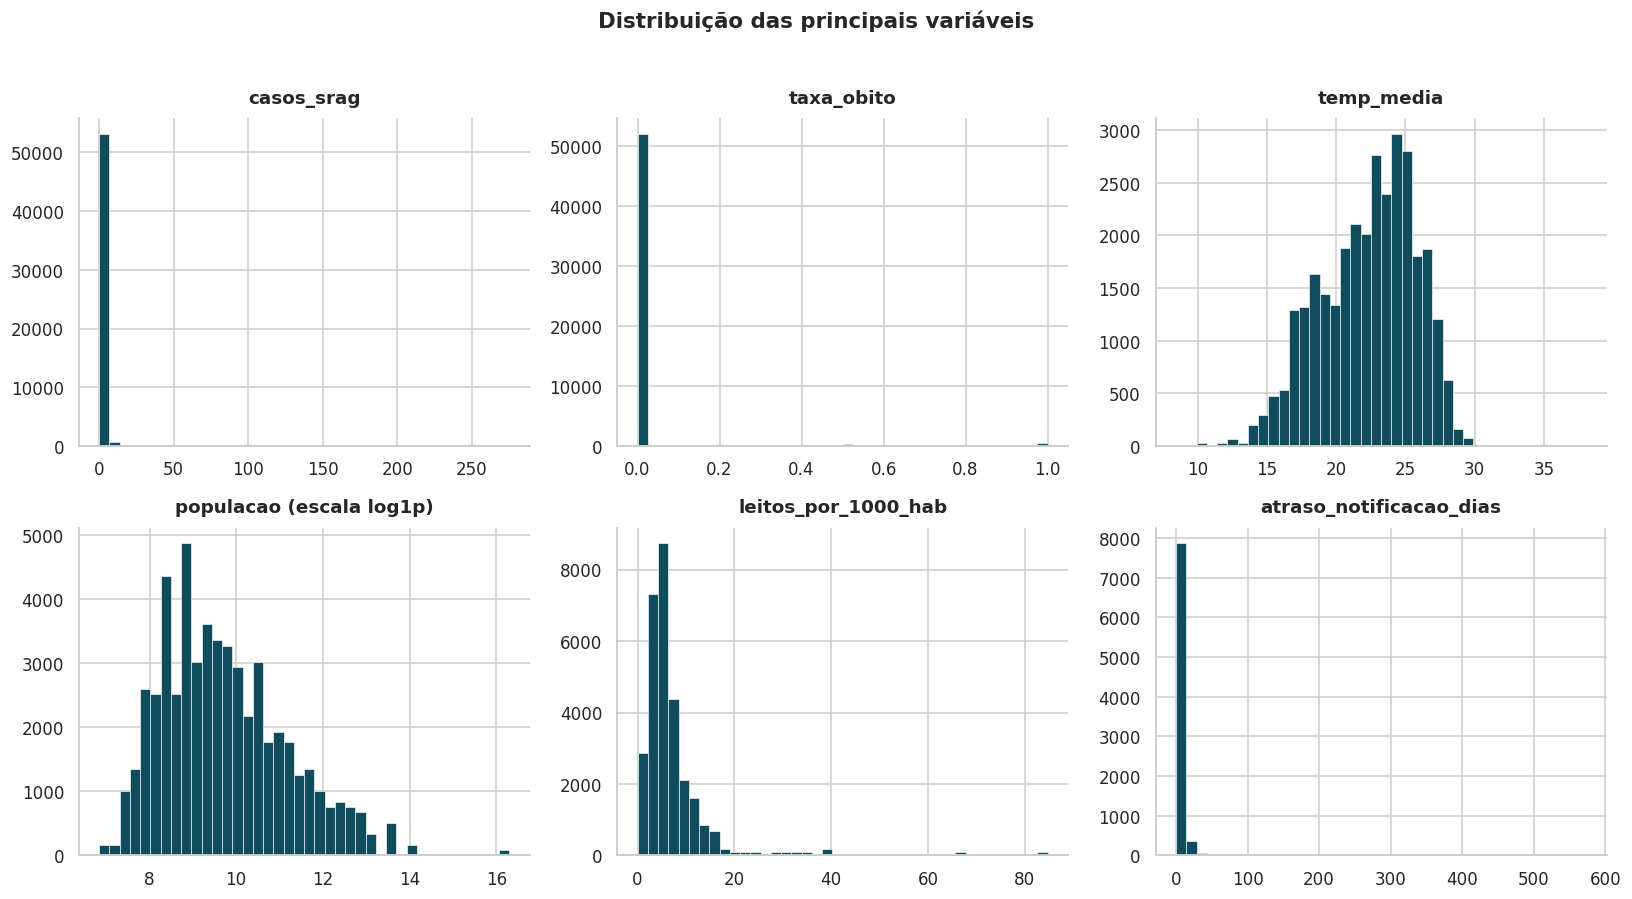

In [9]:
fig, eixos = plt.subplots(2, 3, figsize=(15, 8))
plot_config = [
    ("casos_srag", False), ("taxa_obito", False), ("temp_media", False),
    ("populacao", True), ("leitos_por_1000_hab", False), ("atraso_notificacao_dias", False),
]
for eixo, (coluna, usar_log) in zip(eixos.flat, plot_config):
    dados = df[coluna].dropna()
    dados_plot = np.log1p(dados) if usar_log else dados
    eixo.hist(dados_plot, bins=40, color=COR_PRINCIPAL, edgecolor="white", linewidth=0.4)
    titulo = f"{coluna}" + (" (escala log1p)" if usar_log else "")
    estilizar_eixo(eixo, titulo=titulo)
plt.suptitle("Distribuição das principais variáveis", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


**Leitura:** `temp_media` é a única variável perto de uma distribuição normal (assimetria ≈
−0,4). Todas as demais são fortemente assimétricas à direita, com excesso de zeros e curtose alta
— comportamento típico de vigilância de doença rara em grão fino (município × semana), mais
próximo de uma contagem zero-inflada (Poisson/binomial negativa) do que de uma normal. Isso
descarta testes/métodos que assumem normalidade nessas colunas, e também descarta detecção de
outlier por IQR clássico (ver Seção 6).

## 4. Medidas de localização e variabilidade

In [10]:
colunas_numericas = df.select_dtypes(include=[np.number]).columns.tolist()
descricao_completa = df[colunas_numericas].describe().T
descricao_completa["CV"] = descricao_completa["std"] / descricao_completa["mean"]
descricao_completa.sort_values("CV", ascending=False).round(2).head(15).style.background_gradient(
    subset=["CV"], cmap="OrRd"
)


,count,mean,std,min,25%,50%,75%,max,CV
variacao_temp,30629.000000,0.030000,2.050000,-5.840000,-1.340000,-0.010000,1.130000,7.060000,75.450000
taxa_gestantes,54180.000000,0.000000,0.030000,0.000000,0.000000,0.000000,0.000000,1.000000,25.440000
taxa_cadeia_surto,54180.000000,0.000000,0.040000,0.000000,0.000000,0.000000,0.000000,1.000000,18.570000
casos_influenza,54180.000000,0.130000,1.600000,0.000000,0.000000,0.000000,0.000000,123.000000,12.430000
taxa_zona_rural,54180.000000,0.010000,0.070000,0.000000,0.000000,0.000000,0.000000,1.000000,12.410000
casos_covid,54180.000000,0.050000,0.570000,0.000000,0.000000,0.000000,0.000000,48.000000,11.000000
casos_uti,54180.000000,0.180000,1.640000,0.000000,0.000000,0.000000,0.000000,74.000000,9.070000
obitos,54180.000000,0.070000,0.660000,0.000000,0.000000,0.000000,0.000000,39.000000,8.870000
casos_vacinados,54180.000000,0.190000,1.680000,0.000000,0.000000,0.000000,0.000000,78.000000,8.860000
casos_idosos,54180.000000,0.220000,1.880000,0.000000,0.000000,0.000000,0.000000,98.000000,8.720000


O coeficiente de variação (CV = desvio padrão / média) passa de **4** em praticamente toda
variável de contagem ou taxa — o desvio padrão chega a ser 15-20× maior que a média. A mediana
(que fica em 0 na maioria) e o % de zeros contam a história real melhor do que a média sozinha.

## 5. Valores faltantes

O padrão de missing tem duas causas estruturais (a terceira causa, municípios fora de SP, já foi
corrigida no ETL — ver nota de versão no topo do notebook).

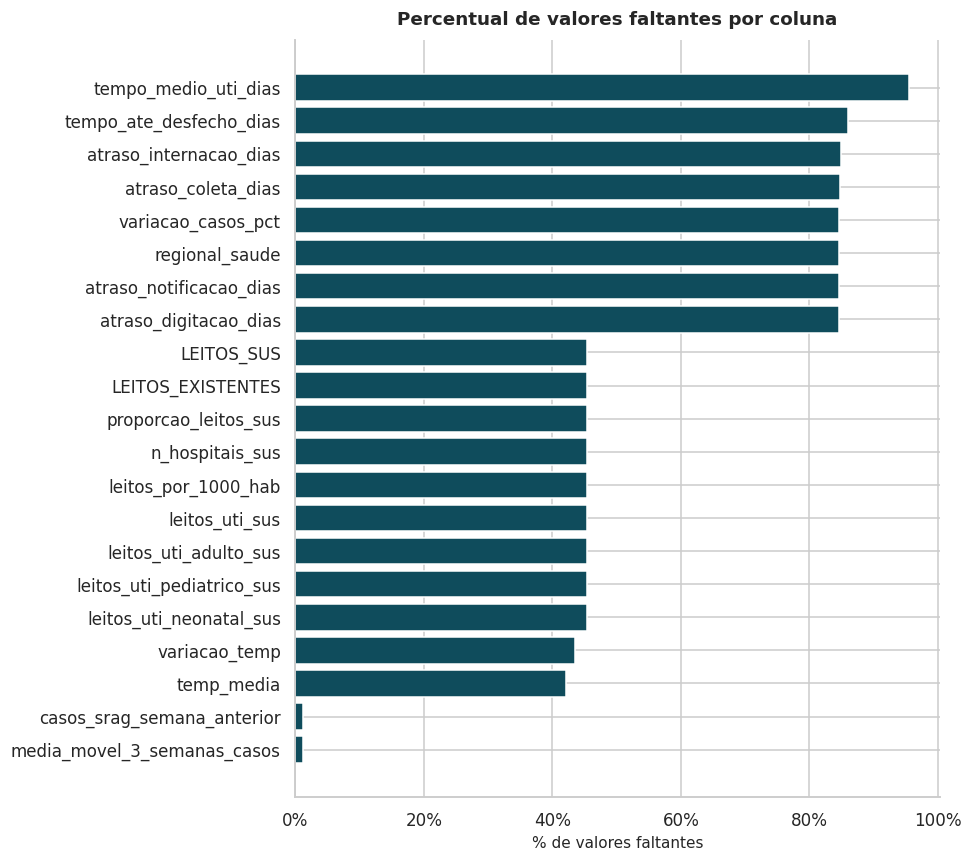

In [11]:
faltantes = (df.isna().mean() * 100).sort_values(ascending=False)
faltantes = faltantes[faltantes > 0]

fig, eixo = plt.subplots(figsize=(9, 8))
eixo.barh(faltantes.index[::-1], faltantes.values[::-1], color=COR_PRINCIPAL)
estilizar_eixo(eixo, titulo="Percentual de valores faltantes por coluna", xlabel="% de valores faltantes")
eixo.xaxis.set_major_formatter(mticker.PercentFormatter())
plt.tight_layout()
plt.show()


In [12]:
pct_sem_caso = (df["casos_srag"] == 0).mean() * 100
pct_regional_nula_sem_caso = ((df["casos_srag"] == 0) & (df["regional_saude"].isna())).mean() * 100
print("Causa 1 — campos que só existem quando há caso na semana:")
print(f"  % de linhas sem nenhum caso de SRAG: {pct_sem_caso:.2f}%")
print(f"  % de linhas sem caso E com regional_saude nula: {pct_regional_nula_sem_caso:.2f}%  (mesmo valor — confirma a causa)")
print()

municipios_sem_leitos = df.groupby("municipio")["LEITOS_SUS"].apply(lambda s: s.isna().all())
print("Causa 2 — municípios pequenos sem hospital SUS cadastrado no CNES:")
print(f"  {municipios_sem_leitos.sum()} de {municipios_sem_leitos.shape[0]} municípios não têm NENHUM dado de leitos SUS.")
print("  Faltante aqui não significa 'desconhecido' — significa 'zero leitos', um dado real.")


Causa 1 — campos que só existem quando há caso na semana:
  % de linhas sem nenhum caso de SRAG: 84.53%
  % de linhas sem caso E com regional_saude nula: 84.53%  (mesmo valor — confirma a causa)

Causa 2 — municípios pequenos sem hospital SUS cadastrado no CNES:
  293 de 645 municípios não têm NENHUM dado de leitos SUS.
  Faltante aqui não significa 'desconhecido' — significa 'zero leitos', um dado real.


**Estratégia de imputação, por grupo:**

| Grupo | Colunas | Estratégia | Justificativa |
|---|---|---|---|
| Sem caso na semana | `regional_saude`, `atraso_*_dias`, `tempo_medio_uti_dias`, `tempo_ate_desfecho_dias`, `variacao_casos_pct` | manter `NaN` | preencher com 0 seria informação falsa (não é "instantâneo", é "não existe") |
| Município sem hospital SUS | `LEITOS_SUS` e derivadas | imputar **0** | ausência real de leito, não desconhecimento |
| Primeira semana de cada município | `variacao_temp`, `casos_srag_semana_anterior`, `media_movel_3_semanas_casos` | manter `NaN` | não existe semana anterior pra comparar |


## 6. Outliers

**Alerta metodológico primeiro:** IQR clássico não funciona nas variáveis de contagem — o
excesso de zeros faz Q1 = Q3 = 0, e qualquer valor positivo vira "outlier".

In [13]:
s = df["casos_srag"]
q1, q3 = s.quantile(.25), s.quantile(.75)
n_outliers = (s > q3 + 1.5*(q3-q1)).sum()
print(f"Q1 = {q1}, Q3 = {q3} → limite superior = {q3 + 1.5*(q3-q1)}")
print(f"IQR classificaria {n_outliers} linhas ({n_outliers/len(s)*100:.1f}%) como outlier —")
print("basicamente toda linha com pelo menos 1 caso. O método não serve pra essa variável.")


Q1 = 0.0, Q3 = 0.0 → limite superior = 0.0
IQR classificaria 8383 linhas (15.5%) como outlier —
basicamente toda linha com pelo menos 1 caso. O método não serve pra essa variável.


**Decisão:** valores extremos genuínos (picos de `casos_srag`) são mantidos — são o sinal
epidemiológico que o projeto quer detectar. Só tratamos **inconsistências lógicas** (valor
impossível, não valor raro):

In [14]:
neg_interna = (df["atraso_internacao_dias"] < 0).sum()
neg_digita = (df["atraso_digitacao_dias"] < 0).sum()
acima_1 = (df["taxa_positividade_antigenico"] > 1).sum()
tabagismo_variancia = df["taxa_tabagismo"].nunique()

print(f"• atraso_internacao_dias < 0 (internação antes do 1º sintoma): {neg_interna} linhas")
print(f"• atraso_digitacao_dias < 0 (digitação antes da notificação): {neg_digita} linhas")
print(f"• taxa_positividade_antigenico > 1 (proporção impossível): {acima_1} linha(s)")
print(f"• taxa_tabagismo tem só {tabagismo_variancia} valor único (sempre 0) — campo TABAG")
print("  provavelmente não veio no CSV bruto do SIVEP. Coluna sem poder preditivo do jeito que está.")
print()
print(f"Total de linhas com inconsistência lógica: {neg_interna + neg_digita + acima_1} de {len(df):,} "
      f"({(neg_interna+neg_digita+acima_1)/len(df)*100:.2f}%) — poucas o bastante pra corrigir pra NaN "
      f"sem impacto relevante no volume de dados.")


• atraso_internacao_dias < 0 (internação antes do 1º sintoma): 48 linhas
• atraso_digitacao_dias < 0 (digitação antes da notificação): 6 linhas
• taxa_positividade_antigenico > 1 (proporção impossível): 1 linha(s)
• taxa_tabagismo tem só 1 valor único (sempre 0) — campo TABAG
  provavelmente não veio no CSV bruto do SIVEP. Coluna sem poder preditivo do jeito que está.

Total de linhas com inconsistência lógica: 55 de 54,180 (0.10%) — poucas o bastante pra corrigir pra NaN sem impacto relevante no volume de dados.


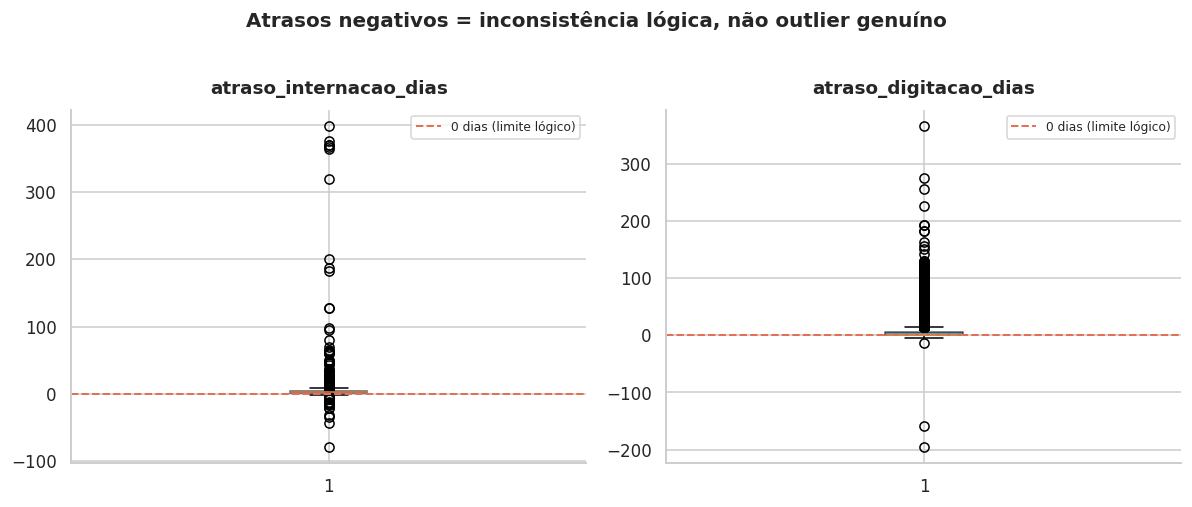

In [15]:
fig, eixos = plt.subplots(1, 2, figsize=(11, 4.5))
for eixo, coluna in zip(eixos, ["atraso_internacao_dias", "atraso_digitacao_dias"]):
    caixa = eixo.boxplot(df[coluna].dropna(), vert=True, patch_artist=True)
    for patch in caixa["boxes"]:
        patch.set_facecolor(COR_PRINCIPAL)
        patch.set_alpha(0.6)
    eixo.axhline(0, color=COR_ALERTA, linestyle="--", linewidth=1.3, label="0 dias (limite lógico)")
    estilizar_eixo(eixo, titulo=coluna)
    eixo.legend(fontsize=8)
plt.suptitle("Atrasos negativos = inconsistência lógica, não outlier genuíno", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


## 7. Relações entre variáveis

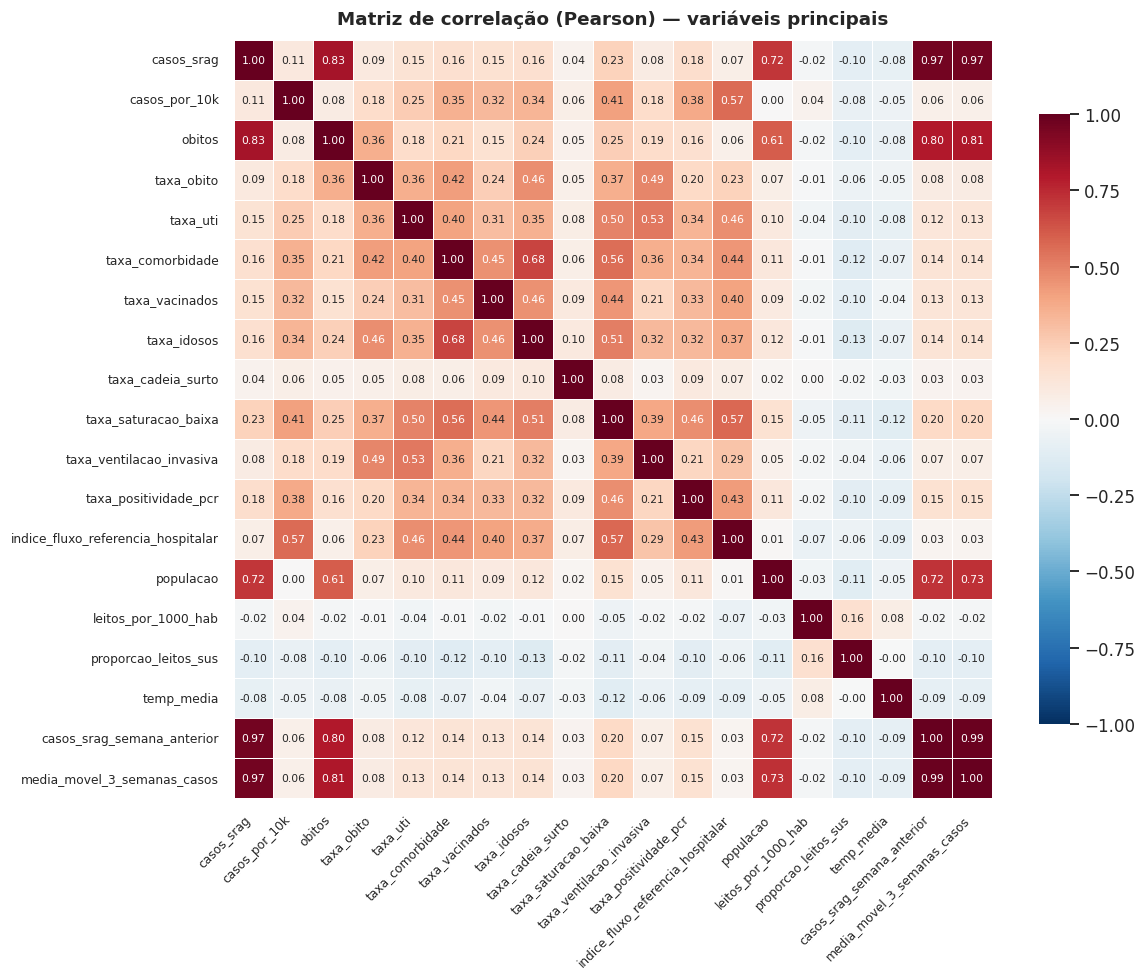

In [16]:
colunas_correlacao = [
    "casos_srag", "casos_por_10k", "obitos", "taxa_obito", "taxa_uti", "taxa_comorbidade",
    "taxa_vacinados", "taxa_idosos", "taxa_cadeia_surto", "taxa_saturacao_baixa",
    "taxa_ventilacao_invasiva", "taxa_positividade_pcr", "indice_fluxo_referencia_hospitalar",
    "populacao", "leitos_por_1000_hab", "proporcao_leitos_sus", "temp_media",
    "casos_srag_semana_anterior", "media_movel_3_semanas_casos",
]
matriz_corr = df[colunas_correlacao].corr()

fig, eixo = plt.subplots(figsize=(11, 9))
sns.heatmap(matriz_corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, ax=eixo, annot_kws={"size": 7}, cbar_kws={"shrink": 0.8})
estilizar_eixo(eixo, titulo="Matriz de correlação (Pearson) — variáveis principais")
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()


**Padrões principais:** `casos_srag` tem forte autocorrelação com a semana anterior e a
média móvel (bom sinal preditivo); `taxa_uti` e `taxa_obito` correlacionam positivamente
(esperado clinicamente); `leitos_por_1000_hab` correlaciona negativamente com `populacao`
(municípios maiores concentram menos leito por habitante — infraestrutura polarizada nos polos
regionais).

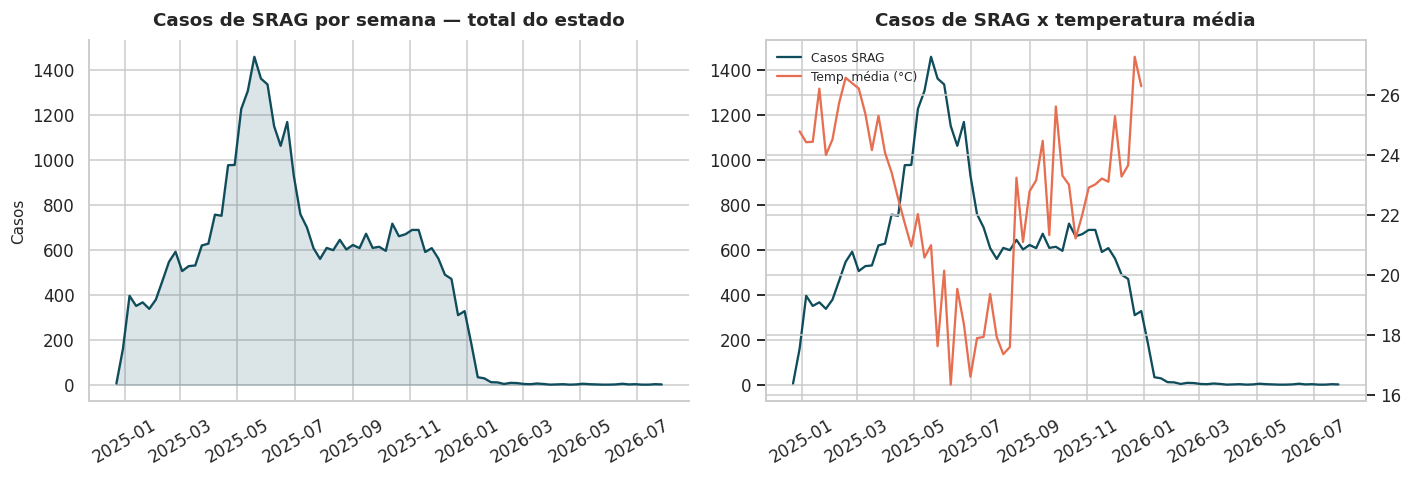

In [17]:
fig, eixos = plt.subplots(1, 2, figsize=(13, 4.5))

serie_semanal = df.groupby("data_formatada")["casos_srag"].sum()
eixos[0].plot(serie_semanal.index, serie_semanal.values, color=COR_PRINCIPAL, linewidth=1.5)
eixos[0].fill_between(serie_semanal.index, serie_semanal.values, color=COR_PRINCIPAL, alpha=0.15)
estilizar_eixo(eixos[0], titulo="Casos de SRAG por semana — total do estado", ylabel="Casos")
eixos[0].tick_params(axis="x", rotation=30)

temp_semanal = df.groupby("data_formatada")["temp_media"].mean()
eixos[1].plot(serie_semanal.index, serie_semanal.values, color=COR_PRINCIPAL, linewidth=1.5, label="Casos SRAG")
eixo2b = eixos[1].twinx()
eixo2b.plot(temp_semanal.index, temp_semanal.values, color=COR_ALERTA, linewidth=1.5, label="Temp. média (°C)")
estilizar_eixo(eixos[1], titulo="Casos de SRAG x temperatura média")
eixos[1].tick_params(axis="x", rotation=30)
l1, r1 = eixos[1].get_legend_handles_labels()
l2, r2 = eixo2b.get_legend_handles_labels()
eixos[1].legend(l1 + l2, r1 + r2, loc="upper left", fontsize=8, frameon=False)

plt.tight_layout()
plt.show()


## 8. Análise regional — qual região concentra mais o problema

Comparação entre as 5 macrorregiões de SP em variáveis relacionadas a SRAG. Usamos **taxas e
proporções**, não contagem bruta — regiões têm população e número de municípios diferentes, e
comparar por contagem absoluta favoreceria injustamente a região mais populosa.

In [18]:
variaveis_srag = [
    "casos_por_10k", "taxa_obito", "taxa_uti", "taxa_comorbidade", "taxa_saturacao_baixa",
    "taxa_dispneia", "taxa_ventilacao_invasiva", "indice_fluxo_referencia_hospitalar",
    "taxa_positividade_pcr", "leitos_por_1000_hab",
]

resumo_regiao = df.groupby("regiao")[variaveis_srag].mean().reindex(ORDEM_REGIOES)

totais_regiao = df.groupby("regiao").agg(
    municipios=("municipio", "nunique"), casos_srag=("casos_srag", "sum"), obitos=("obitos", "sum"),
).reindex(ORDEM_REGIOES)

totais_regiao.style.background_gradient(subset=["casos_srag", "obitos"], cmap="OrRd")


,municipios,casos_srag,obitos
regiao,,,
Centro,138,4765,583
Norte,175,5313,480
Sul,129,17517,1953
Leste,99,8155,916
Oeste,104,985,120


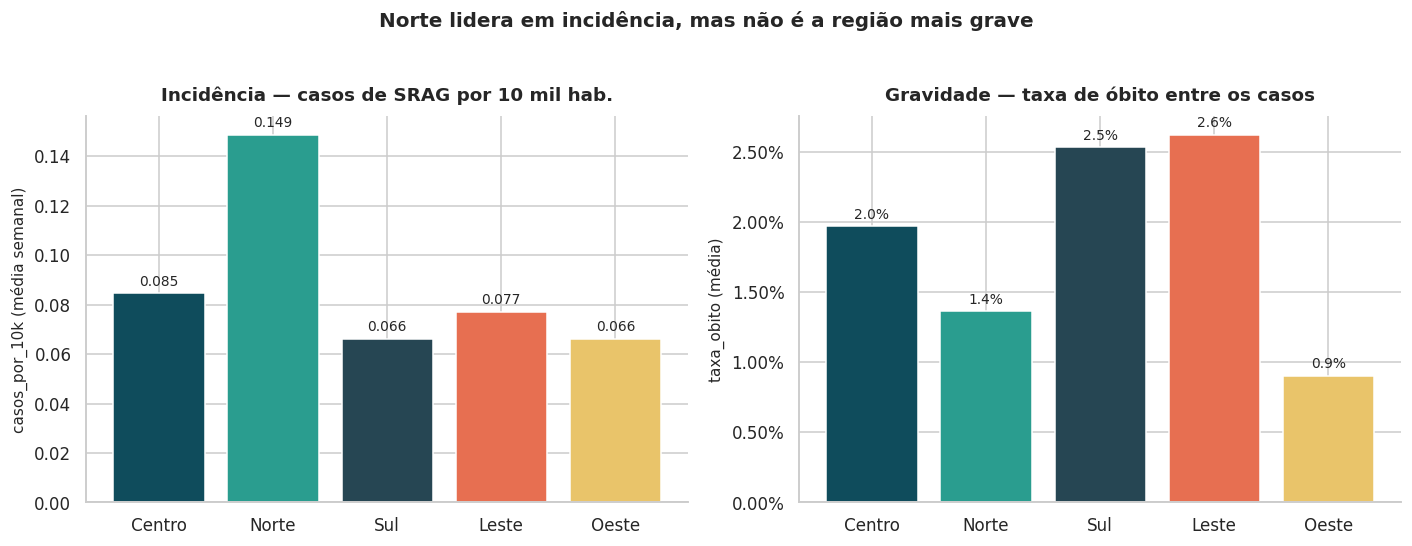

In [19]:
fig, eixos = plt.subplots(1, 2, figsize=(13, 4.8))
cores = [CORES_REGIAO[r] for r in ORDEM_REGIOES]

barras1 = eixos[0].bar(ORDEM_REGIOES, resumo_regiao["casos_por_10k"], color=cores)
estilizar_eixo(eixos[0], titulo="Incidência — casos de SRAG por 10 mil hab.", ylabel="casos_por_10k (média semanal)")
eixos[0].bar_label(barras1, fmt="%.3f", fontsize=9, padding=3)

barras2 = eixos[1].bar(ORDEM_REGIOES, resumo_regiao["taxa_obito"], color=cores)
estilizar_eixo(eixos[1], titulo="Gravidade — taxa de óbito entre os casos", ylabel="taxa_obito (média)")
eixos[1].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
eixos[1].bar_label(barras2, fmt="%.1f%%", labels=[f"{v*100:.1f}%" for v in resumo_regiao["taxa_obito"]], fontsize=9, padding=3)

plt.suptitle("Norte lidera em incidência, mas não é a região mais grave", fontsize=13, fontweight="bold", y=1.03)
plt.tight_layout()
plt.show()


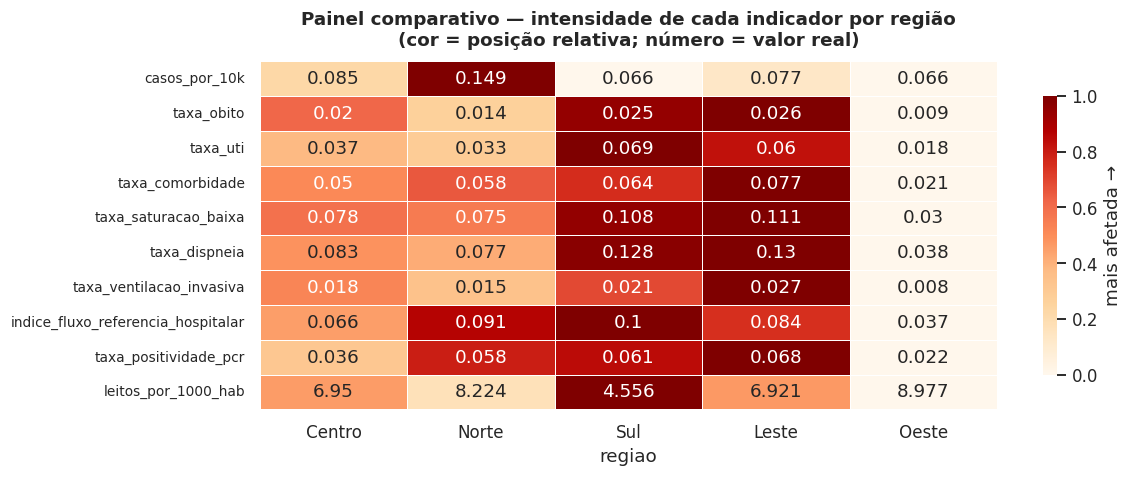

In [20]:
# Heatmap normalizado (0-1 por coluna) — visualiza qual região se destaca em CADA variável ao mesmo tempo
normalizado = (resumo_regiao - resumo_regiao.min()) / (resumo_regiao.max() - resumo_regiao.min())
# leitos_por_1000_hab: menos leito = mais afetado, então invertemos a escala pra manter a leitura consistente
normalizado["leitos_por_1000_hab"] = 1 - normalizado["leitos_por_1000_hab"]

fig, eixo = plt.subplots(figsize=(11, 4.5))
sns.heatmap(normalizado.T, annot=resumo_regiao.T.round(3), fmt="", cmap="OrRd",
            linewidths=0.6, linecolor="white", cbar_kws={"label": "mais afetada →", "shrink": 0.8}, ax=eixo)
estilizar_eixo(eixo, titulo="Painel comparativo — intensidade de cada indicador por região\n(cor = posição relativa; número = valor real)")
plt.xticks(rotation=0)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()


In [21]:
piores = {}
for v in variaveis_srag:
    piores[v] = resumo_regiao[v].idxmin() if v == "leitos_por_1000_hab" else resumo_regiao[v].idxmax()

ranking = pd.Series(piores).value_counts().reindex(ORDEM_REGIOES).fillna(0).astype(int)
print("Em quantas das 10 variáveis cada região aparece como a mais afetada:")
for regiao, contagem in ranking.sort_values(ascending=False).items():
    print(f"  {regiao:8s} {'█' * contagem} {contagem}")


Em quantas das 10 variáveis cada região aparece como a mais afetada:
  Leste    ██████ 6
  Sul      ███ 3
  Norte    █ 1
  Centro    0
  Oeste     0


**Conclusão da análise regional:** a resposta não é uma região só — depende de qual aspecto
do problema se olha:

- **Norte tem a maior incidência** (`casos_por_10k` quase o dobro da segunda colocada) — mas
  paradoxalmente a **menor taxa de óbito**, sugerindo casos numerosos porém em média menos graves,
  e a **maior disponibilidade de leitos por habitante** da região.
- **Leste é a região mais consistentemente afetada em gravidade clínica** — lidera (pior posição)
  em 6 das 10 variáveis: `taxa_obito`, `taxa_comorbidade`, `taxa_saturacao_baixa`, `taxa_dispneia`,
  `taxa_ventilacao_invasiva` e `taxa_positividade_pcr`. Não tem o maior número de casos, mas os
  casos que tem são, em média, mais graves.
- **Sul concentra o maior volume absoluto** de casos e óbitos (é onde fica a Região Metropolitana
  de São Paulo, mais populosa) e tem a **menor oferta de leitos por habitante** e o **maior índice
  de referenciamento hospitalar** — sinal de rede de saúde sob mais pressão relativa, mesmo com
  gravidade clínica per-caso mediana.

**Para o projeto:** se o objetivo é prever *onde* vai faltar estrutura, Sul e a pressão sobre
leitos merece atenção. Se o objetivo é prever *gravidade clínica* por caso, Leste é o sinal mais
forte. Vale considerar `regiao` como feature categórica no Random Forest — o comportamento é
claramente diferente entre elas, não uniforme no estado.

## 9. Conclusão da AED

**Viabilidade dos dados para modelagem preditiva:** o dataset é utilizável para o Random Forest
proposto. A base corrigida cobre os 645 municípios reais de SP, 84 semanas (dez/2024–mar/2026*
conforme o corte de dados atual), com boa cobertura de variáveis clínicas, de capacidade
hospitalar e climáticas.

**Principais achados:**

1. **Variáveis de contagem e taxa são fortemente zero-infladas e assimétricas** — só `temp_media`
   se aproxima de uma normal. Isso invalida testes que assumem normalidade e a detecção de
   outlier por IQR clássico nessas colunas (Q1 = Q3 = 0 faz qualquer caso virar "outlier").
2. **O missing tem 2 causas estruturais** (a terceira, municípios fora de SP, já foi corrigida no
   ETL): campos que só existem quando há caso na semana → manter `NaN`; municípios sem hospital
   SUS cadastrado → imputar 0 nos leitos.
3. **Inconsistências lógicas pontuais** (datas fora de ordem, uma taxa de positividade acima de
   100%) em menos de 0,1% das linhas — poucas o bastante pra corrigir pra `NaN` sem impacto.
4. **`taxa_tabagismo` está com variância zero** — indício de que o campo de origem não veio no
   CSV bruto do SIVEP. Investigar a extração antes de usar a coluna no modelo.
5. **Há autocorrelação temporal forte em `casos_srag`** e sazonalidade visível na série agregada
   — bons preditores pra antecedência de pelo menos 1 mês que o projeto busca.
6. **O comportamento regional não é uniforme**: Norte concentra incidência, Leste concentra
   gravidade clínica, Sul concentra volume absoluto e pressão sobre a rede hospitalar. `regiao`
   deve entrar como feature categórica no modelo.

**Implicações para a próxima etapa (modelagem):**

- Preferir Random Forest / modelos de árvore — lidam bem com `NaN` estrutural e não exigem
  normalidade, evitando imputação artificial nas colunas de atraso/tempo.
- Considerar transformação log ou binarização (houve/não houve surto) para `casos_srag` como alvo,
  dado o grau de assimetria.
- Incluir `regiao`, sazonalidade (semana do ano) e histórico (semana anterior, média móvel) como
  features — todos já confirmados como sinais relevantes nesta AED.
- Investigar e corrigir a extração de `TABAG` antes de usar `taxa_tabagismo`.

*_Ajuste a data conforme o corte real dos dados usados na execução deste notebook._
